# Мультимодальная классификация видео по жанру

**Вход:** видеофайл → CLIP-эмбеддинги кадров + MFCC аудио + технические метаданные  
**Выход:** жанр (категория YouTube)

---
## Содержание
1. Загрузка эмбеддингов
2. Сборка признаков и разбивка на train/test
3. Baseline — Logistic Regression на конкатенации
4. MLP-классификатор (PyTorch)
5. Сравнение модальностей

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

EMB_DIR = Path('data/embeddings')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


---
## 1. Загрузка эмбеддингов

In [56]:
manifest = pd.read_csv(EMB_DIR / 'manifest.csv')
manifest = manifest[manifest['status'] == 'ok'].reset_index(drop=True)
print(f'Успешно загружено: {len(manifest)} видео')
print(manifest['category'].value_counts())

Успешно загружено: 945 видео
category
People & Blogs          242
Entertainment           133
Comedy                   91
Sports                   82
Music                    79
Autos & Vehicles         75
Gaming                   68
Film & Animation         40
Pets & Animals           33
Travel & Events          26
Education                22
Howto & Style            21
News & Politics          16
Science & Technology     10
Nonprofits & Activis      7
Name: count, dtype: int64


In [57]:
visuals, audios, metas, labels = [], [], [], []

for _, row in manifest.iterrows():
    npz = np.load(EMB_DIR / f"{row['video_id']}.npz")
    visuals.append(npz['visual'])
    audios.append(npz['audio'])
    metas.append(npz['meta'])
    labels.append(row['category'])

V = np.stack(visuals)   # (N, 512)
A = np.stack(audios)    # (N, 80)
M = np.stack(metas)     # (N, 5)

print(f'Visual: {V.shape}, Audio: {A.shape}, Meta: {M.shape}')

Visual: (945, 512), Audio: (945, 80), Meta: (945, 5)


---
## 2. Сборка признаков и разбивка на train/test

In [58]:
# Отсекаем категории с менее чем 2 примерами (stratify требует минимум 2)
counts = pd.Series(labels).value_counts()
valid_cats = counts[counts >= 2].index
mask = np.array([l in valid_cats for l in labels])

V_f, A_f, M_f = V[mask], A[mask], M[mask]
labels_f = [l for l, m in zip(labels, mask) if m]

dropped = counts[counts < 2].index.tolist()
if dropped:
    print(f'Отброшены редкие категории ({len(dropped)}): {dropped}')
print(f'Осталось: {len(labels_f)} видео, {len(valid_cats)} категорий')

# Кодируем метки
le = LabelEncoder()
y = le.fit_transform(labels_f)
print('Классы:', list(le.classes_))

# Нормализуем каждую модальность отдельно
scaler_v = StandardScaler()
scaler_a = StandardScaler()
scaler_m = StandardScaler()

V_s = scaler_v.fit_transform(V_f)
A_s = scaler_a.fit_transform(A_f)
M_s = scaler_m.fit_transform(M_f)

# Конкатенация всех модальностей
X = np.concatenate([V_s, A_s, M_s], axis=1)  # (N, 597)
print(f'X shape: {X.shape}')

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Осталось: 945 видео, 15 категорий
Классы: [np.str_('Autos & Vehicles'), np.str_('Comedy'), np.str_('Education'), np.str_('Entertainment'), np.str_('Film & Animation'), np.str_('Gaming'), np.str_('Howto & Style'), np.str_('Music'), np.str_('News & Politics'), np.str_('Nonprofits & Activis'), np.str_('People & Blogs'), np.str_('Pets & Animals'), np.str_('Science & Technology'), np.str_('Sports'), np.str_('Travel & Events')]
X shape: (945, 597)
Train: 756 | Test: 189


---
## 3. Baseline — Logistic Regression

Быстрая проверка: насколько хорошо работает простая линейная модель поверх эмбеддингов.

In [59]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

present = np.unique(y_test)
print(classification_report(
    y_test, y_pred_lr,
    labels=present,
    target_names=le.classes_[present],
    zero_division=0,
))

                      precision    recall  f1-score   support

    Autos & Vehicles       0.91      0.67      0.77        15
              Comedy       0.32      0.39      0.35        18
           Education       0.00      0.00      0.00         4
       Entertainment       0.18      0.22      0.20        27
    Film & Animation       0.00      0.00      0.00         8
              Gaming       0.52      0.86      0.65        14
       Howto & Style       0.50      0.25      0.33         4
               Music       0.47      0.50      0.48        16
     News & Politics       0.00      0.00      0.00         3
Nonprofits & Activis       0.00      0.00      0.00         1
      People & Blogs       0.29      0.29      0.29        49
      Pets & Animals       0.75      0.43      0.55         7
Science & Technology       0.00      0.00      0.00         2
              Sports       0.50      0.56      0.53        16
     Travel & Events       0.00      0.00      0.00         5

      

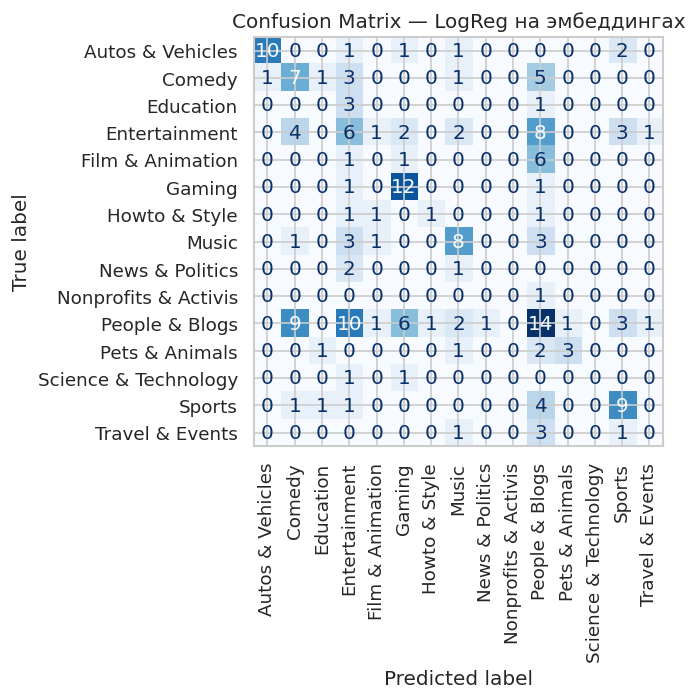

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    labels=present,
    display_labels=le.classes_[present],
    xticks_rotation='vertical',
    cmap='Blues', ax=ax, colorbar=False,
)
ax.set_title('Confusion Matrix — LogReg на эмбеддингах')
plt.tight_layout()
plt.show()

---
## 4. MLP-классификатор (PyTorch)

Трёхслойный MLP с BatchNorm и Dropout.

In [61]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_loaders(X_tr, y_tr, X_te, y_te, batch_size=32):
    tr = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    te = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))
    return (
        DataLoader(tr, batch_size=batch_size, shuffle=True),
        DataLoader(te, batch_size=batch_size),
    )


def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        out = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct += (out.argmax(1) == y_b).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        out = model(X_b)
        total_loss += criterion(out, y_b).item() * len(y_b)
        correct += (out.argmax(1) == y_b).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

In [62]:
NUM_CLASSES = len(le.classes_)
INPUT_DIM = X.shape[1]  # 597
EPOCHS = 100

train_loader, test_loader = make_loaders(X_train, y_train, X_test, y_test)

mlp = MLPClassifier(INPUT_DIM, NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

history = []
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train(mlp, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(mlp, test_loader, criterion)
    history.append((tr_loss, tr_acc, val_loss, val_acc))
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | train acc {tr_acc:.3f} | val acc {val_acc:.3f}')

Epoch  10 | train acc 0.907 | val acc 0.439
Epoch  20 | train acc 0.987 | val acc 0.397
Epoch  30 | train acc 0.991 | val acc 0.381
Epoch  40 | train acc 0.989 | val acc 0.392
Epoch  50 | train acc 0.991 | val acc 0.376
Epoch  60 | train acc 0.984 | val acc 0.413
Epoch  70 | train acc 0.991 | val acc 0.397
Epoch  80 | train acc 0.992 | val acc 0.407
Epoch  90 | train acc 0.997 | val acc 0.386
Epoch 100 | train acc 0.985 | val acc 0.407


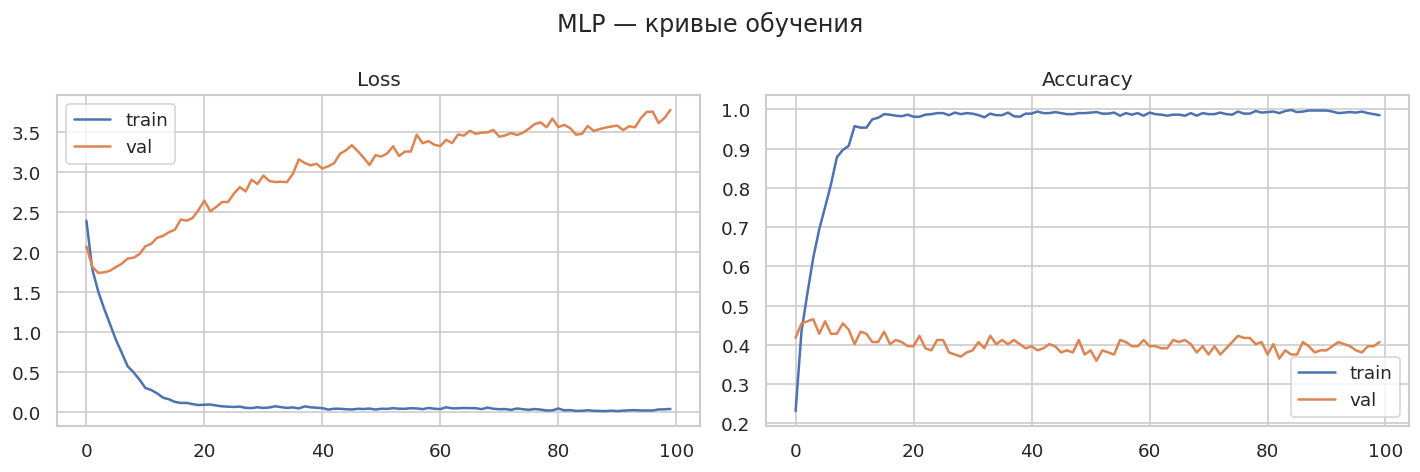

In [63]:
hist = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist[:, 0], label='train')
axes[0].plot(hist[:, 2], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(hist[:, 1], label='train')
axes[1].plot(hist[:, 3], label='val')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.suptitle('MLP — кривые обучения')
plt.tight_layout()
plt.show()

In [64]:
mlp.eval()
with torch.no_grad():
    y_pred_mlp = mlp(
        torch.FloatTensor(X_test).to(DEVICE)
    ).argmax(1).cpu().numpy()

present = np.unique(y_test)
print(classification_report(
    y_test, y_pred_mlp,
    labels=present,
    target_names=le.classes_[present],
    zero_division=0,
))

                      precision    recall  f1-score   support

    Autos & Vehicles       0.62      0.67      0.65        15
              Comedy       0.35      0.39      0.37        18
           Education       0.00      0.00      0.00         4
       Entertainment       0.24      0.26      0.25        27
    Film & Animation       0.00      0.00      0.00         8
              Gaming       0.54      0.93      0.68        14
       Howto & Style       0.50      0.25      0.33         4
               Music       0.57      0.50      0.53        16
     News & Politics       0.00      0.00      0.00         3
Nonprofits & Activis       0.00      0.00      0.00         1
      People & Blogs       0.33      0.33      0.33        49
      Pets & Animals       0.67      0.57      0.62         7
Science & Technology       0.00      0.00      0.00         2
              Sports       0.55      0.69      0.61        16
     Travel & Events       0.00      0.00      0.00         5

      

---
## 5. Сравнение модальностей

Проверим вклад каждой модальности по отдельности.

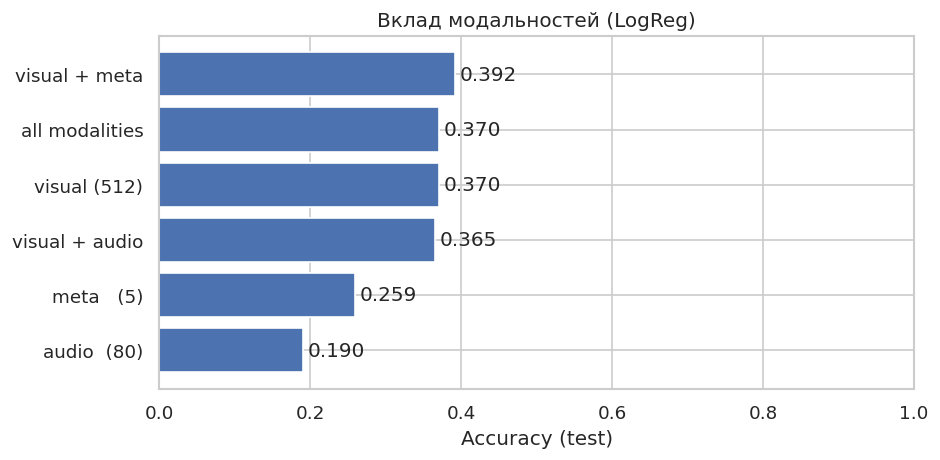

In [65]:
def logreg_acc(X_tr, X_te, y_tr, y_te):
    m = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    m.fit(X_tr, y_tr)
    return m.score(X_te, y_te)

splits = {
    'visual (512)':        (V_s, 0, 512),
    'audio  (80)':         (A_s, None, None),
    'meta   (5)':          (M_s, None, None),
    'visual + audio':      (np.concatenate([V_s, A_s], axis=1), None, None),
    'visual + meta':       (np.concatenate([V_s, M_s], axis=1), None, None),
    'all modalities':      (X,   None, None),
}

results = {}
for name, (feat, *_) in splits.items():
    Xtr, Xte, ytr, yte = train_test_split(feat, y, test_size=0.2, random_state=42, stratify=y)
    results[name] = logreg_acc(Xtr, Xte, ytr, yte)

res_df = pd.Series(results).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(res_df.index, res_df.values)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Accuracy (test)')
ax.set_title('Вклад модальностей (LogReg)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()